# Deck Archetype Trends

Track curated Deck archetypes, team switching, and field matchups across configurable calendar-day replay snapshots. Run `deck/trend_extract.py` before this notebook.

## Goal

This baseline uses only the project's ordered `ARCHETYPE_RULES`. Every unmatched 60-card Deck is grouped into `Other`; fallback main-Pokemon labels are intentionally disabled.

## Setup and Configuration

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml


def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        direct = candidate
        nested = candidate / 'imitation_learning'
        if (direct / 'deck' / 'trend.py').is_file():
            return direct
        if (nested / 'deck' / 'trend.py').is_file():
            return nested
    raise FileNotFoundError('Could not locate imitation_learning project root')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from deck.analysis import CardCatalog
from deck.trend import (
    add_trend_archetypes,
    build_daily_metrics,
    build_matchups,
    build_pooled_archetype_shares,
    build_team_flows,
    build_team_modal_archetypes,
    daily_share_visibility,
    parse_month_day,
    plot_archetype_sankey,
    select_snapshot_dates,
)

CONFIG_PATH = PROJECT_ROOT / 'cfg' / 'deck_trend.yaml'
CARD_DATA_PATH = PROJECT_ROOT.parent / 'pokemon_tcg_ai_battle' / 'EN_Card_Data.csv'
config = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))
extract_cfg = config['extract']
analysis_cfg = config['analysis']

SNAPSHOT_INTERVAL_DAYS = int(analysis_cfg['snapshot_interval_days'])
START_DATE = analysis_cfg.get('start_date')
END_DATE = analysis_cfg.get('end_date')
MIN_SHARE_PERCENT = float(analysis_cfg['min_share_percent'])
if type(analysis_cfg['snapshot_interval_days']) is not int:
    raise ValueError('analysis.snapshot_interval_days must be an integer')
if type(analysis_cfg['exclude_mirror_matches']) is not bool:
    raise ValueError('analysis.exclude_mirror_matches must be true or false')
EXCLUDE_MIRROR_MATCHES = analysis_cfg['exclude_mirror_matches']

if SNAPSHOT_INTERVAL_DAYS < 1:
    raise ValueError('analysis.snapshot_interval_days must be >= 1')
if MIN_SHARE_PERCENT < 0 or MIN_SHARE_PERCENT > 100:
    raise ValueError('analysis.min_share_percent must be in [0, 100]')

data_dir = Path(extract_cfg['output'])
if not data_dir.is_absolute():
    data_dir = PROJECT_ROOT / data_dir
analysis_dir = data_dir / 'analysis'
analysis_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
print('Config:', CONFIG_PATH)
print('Data:', data_dir)
print('Interval days:', SNAPSHOT_INTERVAL_DAYS)
print('Date bounds:', START_DATE, END_DATE)
print('Minimum displayed share:', MIN_SHARE_PERCENT)

Config: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\cfg\deck_trend.yaml
Data: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend
Interval days: 2
Date bounds: None None
Minimum displayed share: 1.0


## Load and Validate Extracted Data

In [2]:
shard_paths = list(data_dir.glob('*.players.csv.gz'))
if not shard_paths:
    raise FileNotFoundError(
        f'No trend shards found in {data_dir}. Run deck/trend_extract.py first.'
    )
shard_paths.sort(key=lambda path: parse_month_day(path.name.split('.players.csv.gz')[0]))
player_rows = pd.concat(
    [pd.read_csv(path, dtype={'date': str, 'episode_id': str}) for path in shard_paths],
    ignore_index=True,
)
required_columns = {
    'date', 'episode_id', 'player', 'team_name', 'opponent_team_name',
    'deck', 'reward', 'result',
}
missing = required_columns - set(player_rows.columns)
if missing:
    raise ValueError(f'Extracted rows are missing columns: {sorted(missing)}')

pair_sizes = player_rows.groupby(['date', 'episode_id']).size()
assert pair_sizes.eq(2).all(), 'Every replay must have exactly two player rows'
assert player_rows.groupby(['date', 'episode_id'])['player'].apply(
    lambda values: set(values.astype(int)) == {0, 1}
).all(), 'Every replay must contain player indices 0 and 1'
assert player_rows['team_name'].astype(str).str.strip().ne('').all()
assert player_rows['deck'].map(lambda value: len(json.loads(value)) == 60).all()

print(f'Shards: {len(shard_paths):,}')
print(f'Games: {len(player_rows) // 2:,}')
print(f'Player rows: {len(player_rows):,}')
print(f'Unique teams: {player_rows.team_name.nunique():,}')

Shards: 43
Games: 210,667
Player rows: 421,334
Unique teams: 1,781


## Select Date Snapshots

In [3]:
snapshot_dates = select_snapshot_dates(
    player_rows['date'].unique(),
    SNAPSHOT_INTERVAL_DAYS,
    start_date=START_DATE,
    end_date=END_DATE,
)
if not snapshot_dates:
    raise ValueError('No available dates remain after applying the analysis settings')
selected_rows = player_rows[player_rows['date'].isin(snapshot_dates)].copy()
selected_rows['date'] = pd.Categorical(
    selected_rows['date'], categories=snapshot_dates, ordered=True
)
pd.DataFrame({'date': snapshot_dates}).to_csv(
    analysis_dir / 'snapshot_dates.csv', index=False, encoding='utf-8-sig'
)
print('Selected snapshots:', snapshot_dates)
display(selected_rows.groupby('date', observed=True).agg(
    games=('episode_id', lambda values: values.nunique()),
    teams=('team_name', 'nunique'),
).reset_index())

Selected snapshots: ['6.26', '6.28', '6.30', '7.2', '7.4', '7.6', '7.8', '7.10', '7.12', '7.14', '7.16', '7.18', '7.20', '7.22', '7.24', '7.26', '7.28', '7.30', '8.1', '8.3', '8.5', '8.7']


,date,games,teams
0,6.26,5600,585
1,6.28,6002,608
2,6.30,5734,307
3,7.2,5266,125
4,7.4,5133,173
5,7.6,5034,216
6,7.8,5198,172
7,7.10,5226,180
8,7.12,5050,151
9,7.14,4929,117


## Classification Coverage

In [4]:
catalog = CardCatalog.from_csv(CARD_DATA_PATH)
annotated = add_trend_archetypes(selected_rows, catalog)
annotated['date'] = pd.Categorical(
    annotated['date'].astype(str), categories=snapshot_dates, ordered=True
)
coverage = (
    annotated.assign(matched=lambda frame: frame['archetype'].ne('Other'))
    .groupby('date', observed=True)
    .agg(
        player_rows=('archetype', 'size'),
        curated_rows=('matched', 'sum'),
        unique_teams=('team_name', 'nunique'),
    )
    .reset_index()
)
coverage['curated_percent'] = 100 * coverage['curated_rows'] / coverage['player_rows']
coverage['other_percent'] = 100 - coverage['curated_percent']
display(coverage)

,date,player_rows,curated_rows,unique_teams,curated_percent,other_percent
0,6.26,11200,10902,585,97.339286,2.660714
1,6.28,12004,11694,608,97.417527,2.582473
2,6.30,11468,11063,307,96.468434,3.531566
3,7.2,10532,9853,125,93.552981,6.447019
4,7.4,10266,8468,173,82.485876,17.514124
5,7.6,10068,9209,216,91.468017,8.531983
6,7.8,10396,9818,172,94.440169,5.559831
7,7.10,10452,10308,180,98.622273,1.377727
8,7.12,10100,9807,151,97.099010,2.900990
9,7.14,9858,9853,117,99.949280,0.050720


## Archetype Usage and Win Rate

In [5]:
daily_metrics = build_daily_metrics(
    annotated, exclude_mirrors=EXCLUDE_MIRROR_MATCHES
)
daily_metrics['date'] = pd.Categorical(
    daily_metrics['date'].astype(str), categories=snapshot_dates, ordered=True
)
assert np.allclose(
    daily_metrics.groupby('date', observed=True)['share_percent'].sum().to_numpy(),
    100.0,
)
assert daily_metrics['non_mirror_win_rate'].dropna().between(0, 1).all()
daily_visible_mask = daily_share_visibility(
    daily_metrics, MIN_SHARE_PERCENT
)
daily_visible_archetypes = set(
    daily_metrics.loc[daily_visible_mask, 'archetype']
)
pooled_archetype_shares = build_pooled_archetype_shares(daily_metrics)
global_visible_archetypes = set(
    pooled_archetype_shares.loc[
        pooled_archetype_shares['share_percent'] >= MIN_SHARE_PERCENT,
        'archetype',
    ]
)
daily_metrics.to_csv(
    analysis_dir / 'archetype_daily_metrics.csv', index=False, encoding='utf-8-sig'
)
display(daily_metrics.sort_values(['date', 'uses'], ascending=[True, False]))

,date,archetype,uses,share_percent,wins,losses,draws,non_mirror_games,non_mirror_win_rate
0,6.26,Mega Lucario,2422,21.625000,637,1097,0,1734,0.367359
1,6.26,Hop Trevenant,2393,21.366071,876,979,2,1857,0.471729
2,6.26,Alakazam,2090,18.660714,890,831,1,1722,0.516841
3,6.26,Mega Starmie,991,8.848214,481,414,0,895,0.537430
4,6.26,Archaludon,974,8.696429,600,320,0,920,0.652174
...,...,...,...,...,...,...,...,...,...
328,8.7,Mega Kangaskhan,211,2.274197,120,91,0,211,0.568720
329,8.7,N's Zoroark,80,0.862255,60,20,0,80,0.750000
330,8.7,Cynthia Garchomp,79,0.851477,27,52,0,79,0.341772
331,8.7,Team Rocket Mewtwo,41,0.441906,19,22,0,41,0.463415


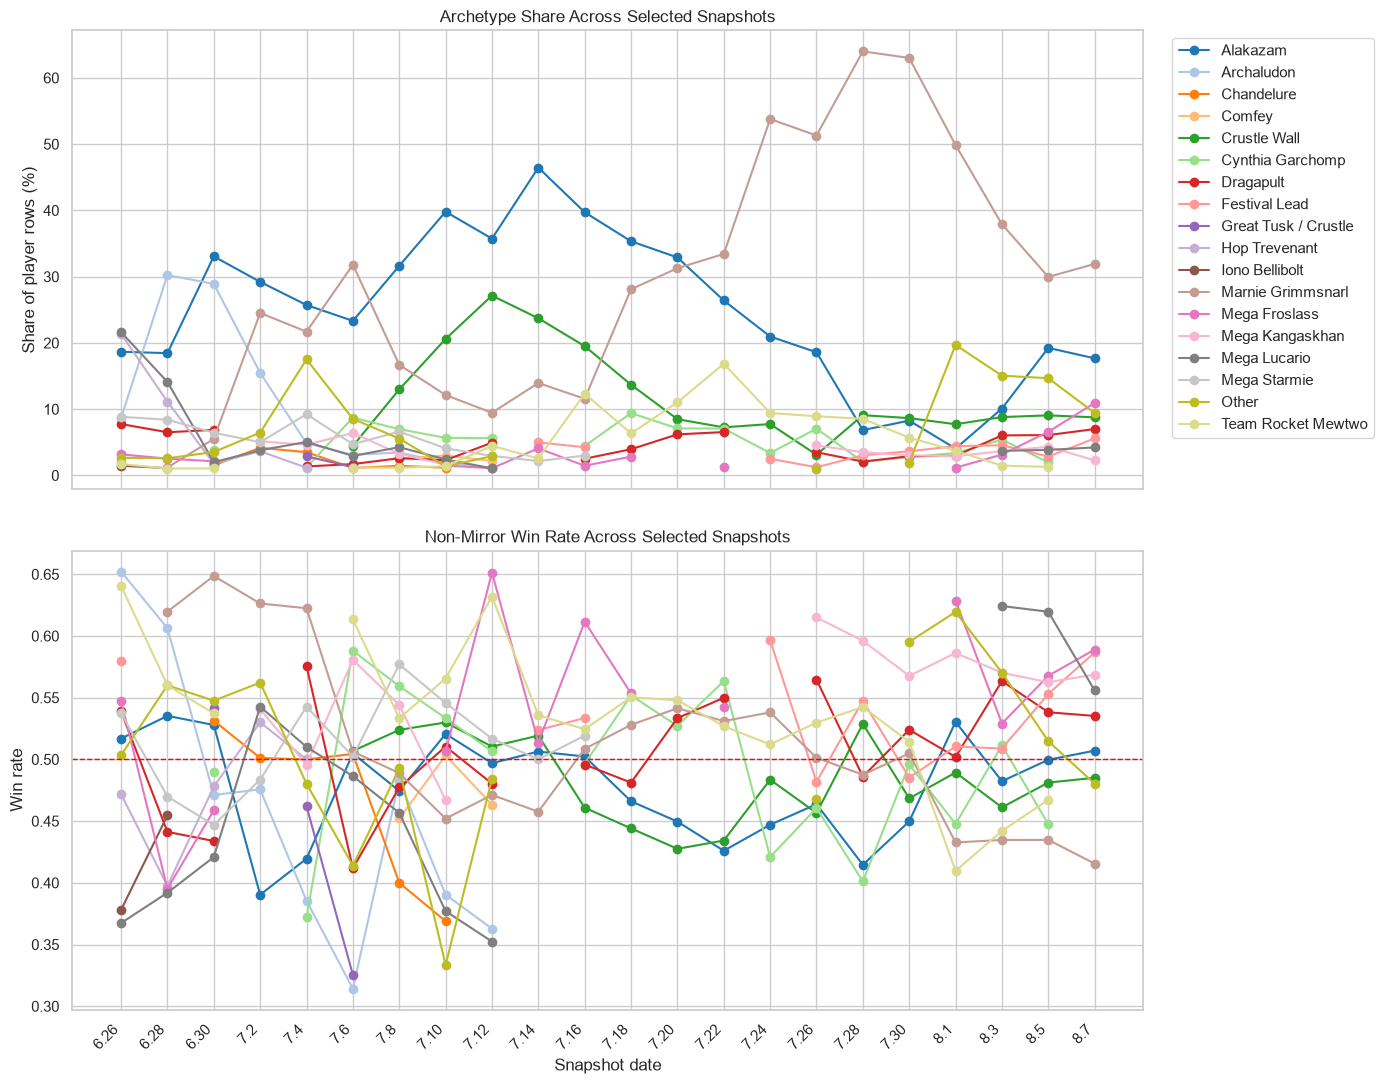

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
date_positions = np.arange(len(snapshot_dates))
line_archetypes = sorted(daily_visible_archetypes)
line_colors = dict(zip(
    line_archetypes, sns.color_palette('tab20', n_colors=len(line_archetypes))
))
for archetype in line_archetypes:
    series = daily_metrics[daily_metrics['archetype'] == archetype].copy()
    series['date'] = series['date'].astype(str)
    series = series.set_index('date').reindex(snapshot_dates)
    visible = series['share_percent'].ge(MIN_SHARE_PERCENT)
    axes[0].plot(
        date_positions, series['share_percent'].where(visible),
        marker='o', linewidth=1.5, label=archetype,
        color=line_colors[archetype],
    )
    axes[1].plot(
        date_positions, series['non_mirror_win_rate'].where(visible),
        marker='o', linewidth=1.5, color=line_colors[archetype],
    )
axes[0].set_title('Archetype Share Across Selected Snapshots')
axes[0].set_ylabel('Share of player rows (%)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Non-Mirror Win Rate Across Selected Snapshots')
axes[1].set_ylabel('Win rate')
axes[1].set_xlabel('Snapshot date')
axes[1].set_xticks(date_positions, snapshot_dates, rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Team Modal Archetypes and Retention

In [7]:
team_modal = build_team_modal_archetypes(annotated)
team_flows, team_retention = build_team_flows(team_modal, snapshot_dates)
team_modal.to_csv(
    analysis_dir / 'team_modal_archetypes.csv', index=False, encoding='utf-8-sig'
)
team_flows.to_csv(
    analysis_dir / 'team_snapshot_flows.csv', index=False, encoding='utf-8-sig'
)
team_retention.to_csv(
    analysis_dir / 'team_retention.csv', index=False, encoding='utf-8-sig'
)
switched_flows = team_flows[
    team_flows['source_archetype'] != team_flows['target_archetype']
]
inflow = switched_flows.groupby('target_archetype')['teams'].sum().rename('inflow')
outflow = switched_flows.groupby('source_archetype')['teams'].sum().rename('outflow')
flow_balance = pd.concat([inflow, outflow], axis=1).fillna(0).astype(int)
flow_balance['net_flow'] = flow_balance['inflow'] - flow_balance['outflow']
display(team_retention)
display(flow_balance.sort_values('net_flow', ascending=False))
display(team_flows.sort_values('teams', ascending=False).head(30))

,from_date,to_date,from_teams,to_teams,overlapping_teams,from_retention_rate,to_retention_rate,unchanged_teams,switched_teams,switch_rate
0,6.26,6.28,585,608,415,0.709402,0.682566,365,50,0.120482
1,6.28,6.30,608,307,220,0.361842,0.716612,188,32,0.145455
2,6.30,7.2,307,125,102,0.332248,0.816000,101,1,0.009804
3,7.2,7.4,125,173,74,0.592000,0.427746,67,7,0.094595
4,7.4,7.6,173,216,100,0.578035,0.462963,88,12,0.120000
5,7.6,7.8,216,172,92,0.425926,0.534884,80,12,0.130435
6,7.8,7.10,172,180,104,0.604651,0.577778,94,10,0.096154
7,7.10,7.12,180,151,80,0.444444,0.529801,68,12,0.150000
8,7.12,7.14,151,117,71,0.470199,0.606838,60,11,0.154930
9,7.14,7.16,117,125,69,0.589744,0.552000,60,9,0.130435


,inflow,outflow,net_flow
Archaludon,43,15,28
Mega Froslass,24,6,18
Other,31,18,13
Marnie Grimmsnarl,107,101,6
Great Tusk / Crustle,5,0,5
Cynthia Garchomp,18,13,5
Dragapult,23,20,3
N's Zoroark,1,0,1
Festival Lead,15,14,1
Comfey,2,2,0


,from_date,to_date,source_archetype,target_archetype,teams
27,6.26,6.28,Mega Lucario,Mega Lucario,116
511,8.5,8.7,Marnie Grimmsnarl,Marnie Grimmsnarl,70
40,6.28,6.30,Archaludon,Archaludon,67
0,6.26,6.28,Alakazam,Alakazam,67
406,7.30,8.1,Marnie Grimmsnarl,Marnie Grimmsnarl,65
470,8.3,8.5,Marnie Grimmsnarl,Marnie Grimmsnarl,62
379,7.28,7.30,Marnie Grimmsnarl,Marnie Grimmsnarl,62
432,8.1,8.3,Marnie Grimmsnarl,Marnie Grimmsnarl,60
16,6.26,6.28,Hop Trevenant,Hop Trevenant,56
354,7.26,7.28,Marnie Grimmsnarl,Marnie Grimmsnarl,49


## Sankey Flow

In [8]:
%pip install -U "nbformat>=4.2.0"

Note: you may need to restart the kernel to use updated packages.


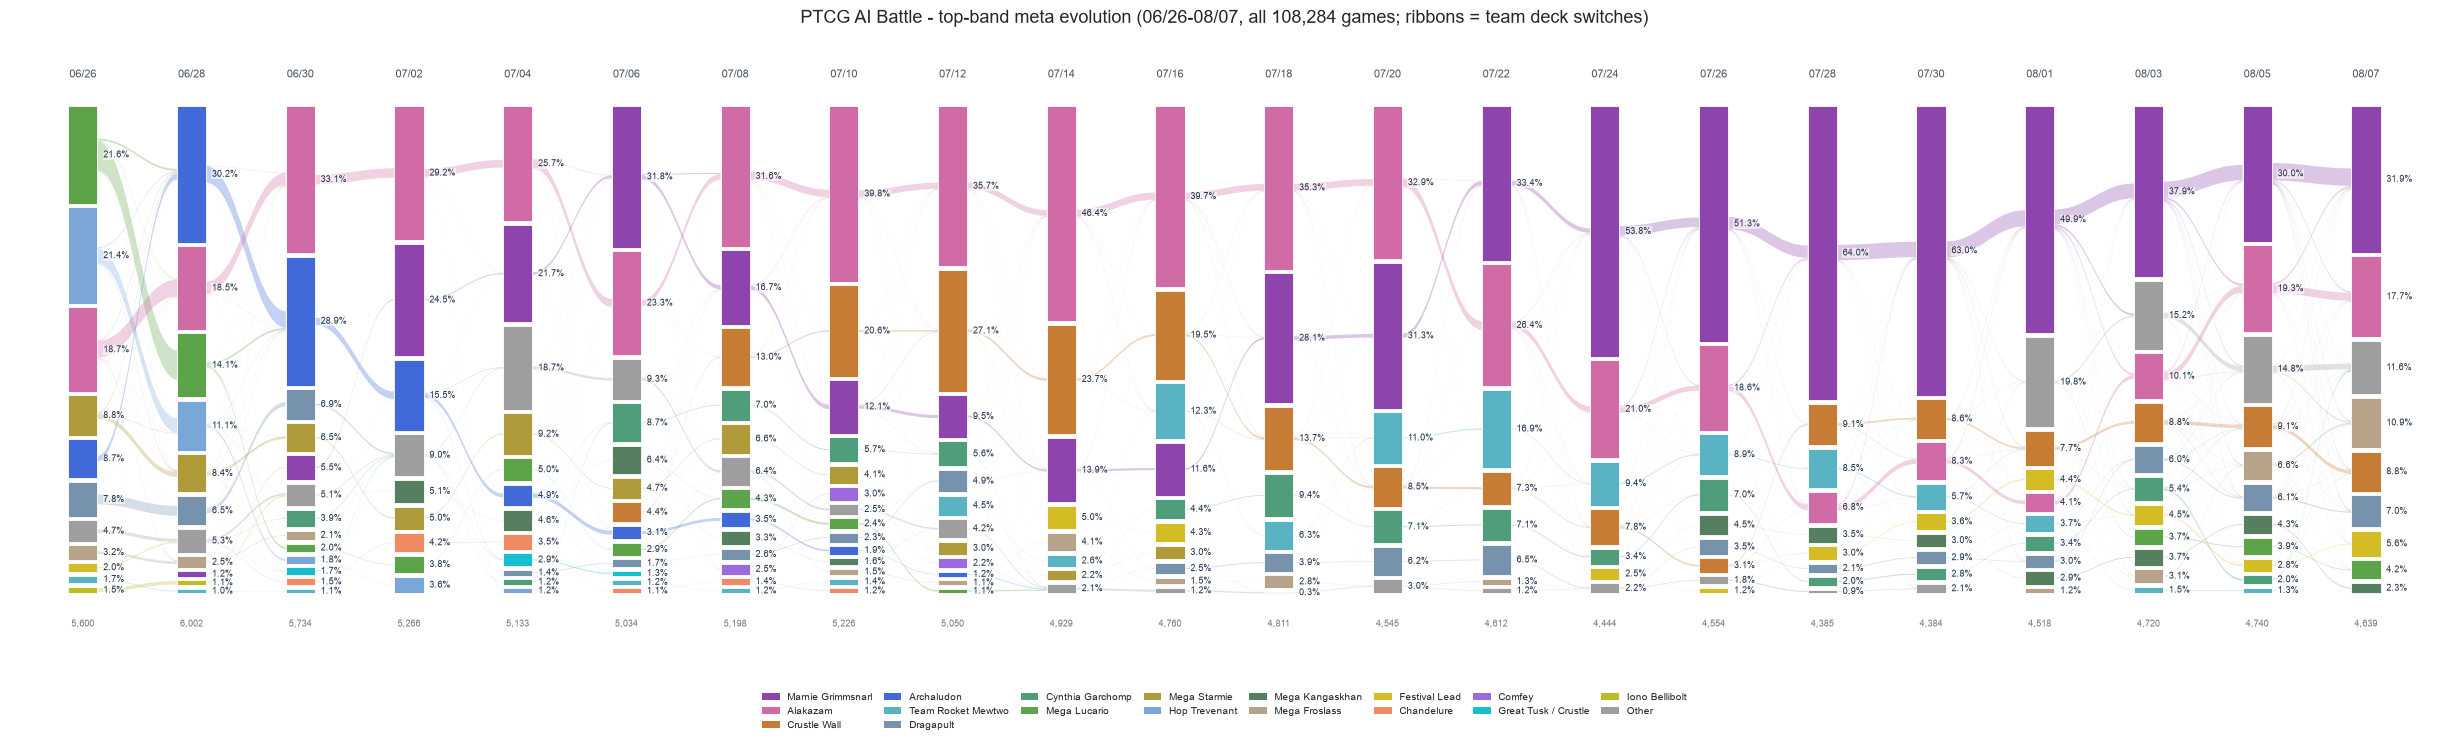

Saved: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend\analysis\archetype_sankey.png


In [9]:
share_lookup = daily_metrics.set_index(['date', 'archetype'])['share_percent'].to_dict()
display_rows = annotated[['date', 'archetype']].copy()
display_rows['display_archetype'] = display_rows.apply(
    lambda row: row['archetype']
    if share_lookup.get((row['date'], row['archetype']), 0) >= MIN_SHARE_PERCENT
    else 'Other',
    axis=1,
)
display_shares = (
    display_rows.groupby(['date', 'display_archetype'], observed=True).size()
    .rename('uses').reset_index()
)
display_shares['share_percent'] = 100 * display_shares['uses'] / (
    display_shares.groupby('date', observed=True)['uses'].transform('sum')
)
display_modal = team_modal.copy()
display_modal['display_archetype'] = display_modal.apply(
    lambda row: row['modal_archetype']
    if share_lookup.get((row['date'], row['modal_archetype']), 0) >= MIN_SHARE_PERCENT
    else 'Other',
    axis=1,
)
display_modal = display_modal.drop(columns='modal_archetype').rename(
    columns={'display_archetype': 'modal_archetype'}
)
display_flows, _ = build_team_flows(display_modal, snapshot_dates)

sankey_figure = plot_archetype_sankey(
    display_shares, display_flows, snapshot_dates
)
sankey_path = analysis_dir / 'archetype_sankey.png'
sankey_figure.savefig(sankey_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', sankey_path)

## Matchup Matrix

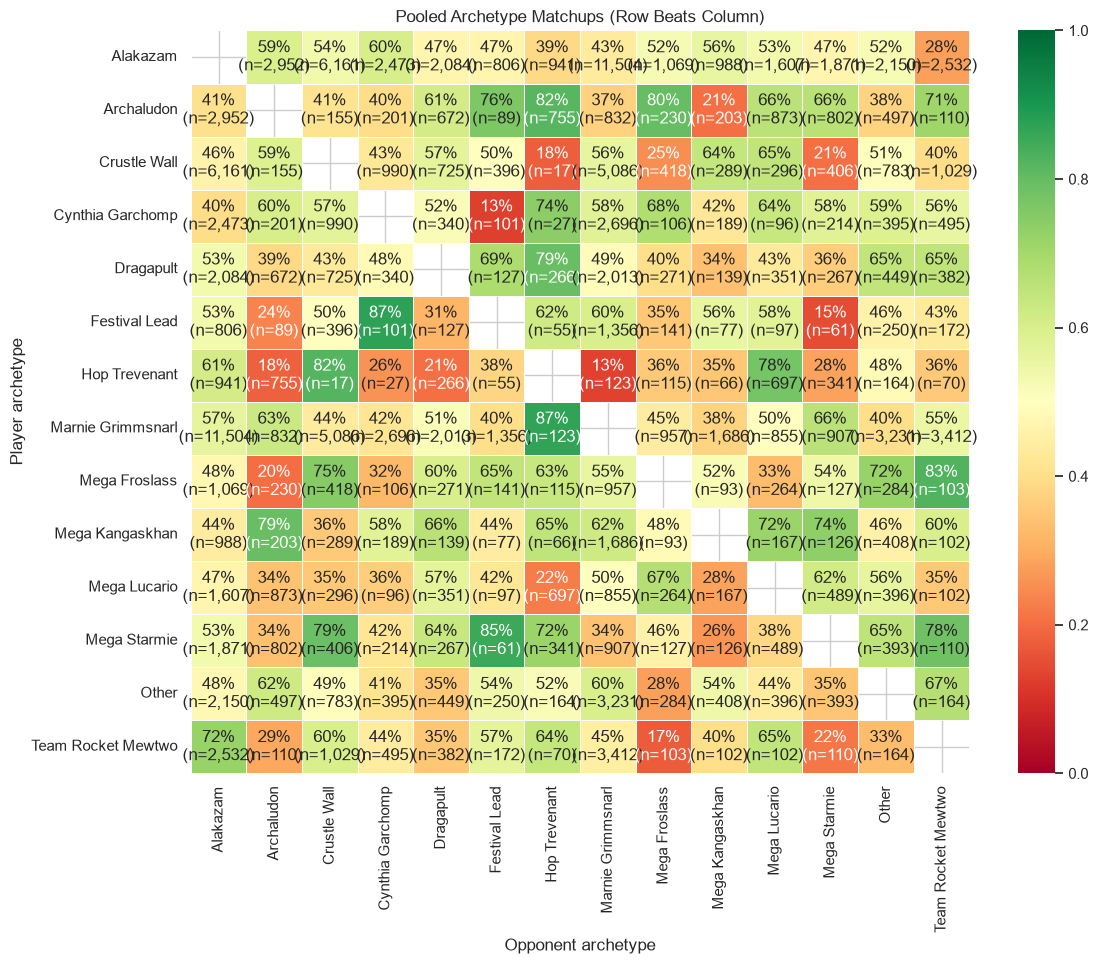

In [10]:
matchups = build_matchups(
    annotated, exclude_mirrors=EXCLUDE_MIRROR_MATCHES
)
assert (matchups['wins'] + matchups['losses'] + matchups['draws']).equals(
    matchups['games']
)
matchups.to_csv(
    analysis_dir / 'matchup_matrix_long.csv', index=False, encoding='utf-8-sig'
)
matrix_archetypes = sorted(
    set(matchups['row_archetype']) & global_visible_archetypes
)
matrix_rows = matchups[
    matchups['row_archetype'].isin(matrix_archetypes)
    & matchups['column_archetype'].isin(matrix_archetypes)
]
win_matrix = matrix_rows.pivot(
    index='row_archetype', columns='column_archetype', values='win_rate'
).reindex(index=matrix_archetypes, columns=matrix_archetypes)
game_matrix = matrix_rows.pivot(
    index='row_archetype', columns='column_archetype', values='games'
).reindex(index=matrix_archetypes, columns=matrix_archetypes)
annotations = win_matrix.copy().astype(object)
for row_name in matrix_archetypes:
    for column_name in matrix_archetypes:
        rate = win_matrix.loc[row_name, column_name]
        games = game_matrix.loc[row_name, column_name]
        annotations.loc[row_name, column_name] = (
            '' if pd.isna(rate) else f'{rate:.0%}\n(n={int(games):,})'
        )
plt.figure(figsize=(max(10, len(matrix_archetypes) * 0.85), max(8, len(matrix_archetypes) * 0.7)))
sns.heatmap(
    win_matrix, annot=annotations, fmt='', cmap='RdYlGn',
    vmin=0, vmax=1, center=0.5, linewidths=0.5,
)
plt.title('Pooled Archetype Matchups (Row Beats Column)')
plt.xlabel('Opponent archetype')
plt.ylabel('Player archetype')
plt.tight_layout()
plt.show()

## Exported Tables

In [11]:
exported = sorted(path.name for path in analysis_dir.glob('*.csv'))
print('Analysis output:', analysis_dir)
for name in exported:
    print('-', name)

Analysis output: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend\analysis
- archetype_daily_metrics.csv
- matchup_matrix_long.csv
- snapshot_dates.csv
- team_modal_archetypes.csv
- team_retention.csv
- team_snapshot_flows.csv


## Takeaways

After execution, review classification coverage before interpreting trends. A large `Other` share means the curated baseline needs more signature rules. Treat matchup rates with small displayed game counts as exploratory rather than stable estimates.